<a href="https://colab.research.google.com/github/Faizan-Rashid/deep-learning-pytorch/blob/main/04_pytorch_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**04.  PyTorch Custom Datasets**

### What is a custom dataset?

A custom dataset is a collection of data relating to a specific problem you're working on.

In essence, a custom dataset can be comprised of almost anything.

 if we were trying to build a model to classify whether or not a text-based review on a website was positive or negative, our custom dataset might be examples of existing customer reviews and their ratings.

Or if we were trying to build a sound classification app, our custom dataset might be sound samples alongside their sample labels.

PyTorch includes many existing functions to load in various custom datasets in the `TorchVision`, `TorchText`, `TorchAudio` and `TorchRec` domain libraries.

But sometimes these existing functions may not be enough.

In that case, we can always subclass torch.utils.data.Dataset and customize it to our liking.

### What is the goal of this module?

We'll use torchvision.datasets as well as our own custom Dataset class to load in images of food and then we'll build a PyTorch computer vision model to hopefully be able to classify them.

## 0. Importing PyTorch and setting up device-agnostic code

In [ ]:
import torch
import torch.nn as nn

torch.__version__

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. Getting Data

In [7]:
from pathlib import Path
import requests
import zipfile

# Path to data folder - setup
data_path = Path("data/")
image_path= data_path / "pizza_steak_sushi"

# If image folder doesn't exists download and prepare it
if image_path.is_dir():
  print(f"{image_path} directory exists")
else:
  print(f"{image_path} directory does not exists. Creating one...")

  image_path.mkdir(parents=True,
                   exist_ok=True)

  # Download pizza, steak, sushi data from the link
  with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/Faizan-Rashid/deep-learning-pytorch/raw/refs/heads/main/extras/data/pizza_steak_sushi.zip")
    print("Downloading pizza steak sushi data...")
    f.write(request.content)

  # Unzip pizza, steak, sushi data
  with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip") as zip_ref:
    print("Unzipping pizza, steak and sushi data...")
    zip_ref.extractall(path=image_path)

data/pizza_steak_sushi directory does not exists. Creating one...
Unzipping pizza, steak and sushi data...


## 2. Data Preparation

Goal: become one with the data, then find a way to best turn it into a dataset compatible with PyTorch.

In [8]:
import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory

  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [9]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.


In [10]:
# trainiing and testing paths

train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

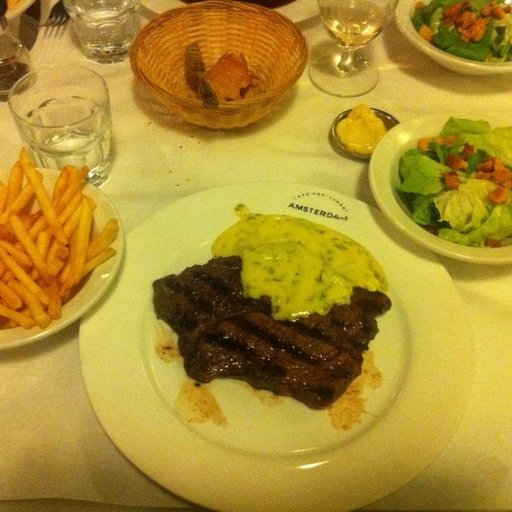

In [11]:
import random
from PIL import Image

img_path_list = list(image_path.glob("*/*/*.jpg"))

random_img_path = random.choice(img_path_list)

img_class = random_img_path.parent.stem

Image.open(random_img_path)

## 3. Transform data



In [12]:
import torch
from  torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with torchvision.transforms

We've got folders of images but before we can use them with PyTorch, we need to convert them into tensors.

One of the ways we can do this is by using the torchvision.transforms module.

In [13]:
transform_data = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

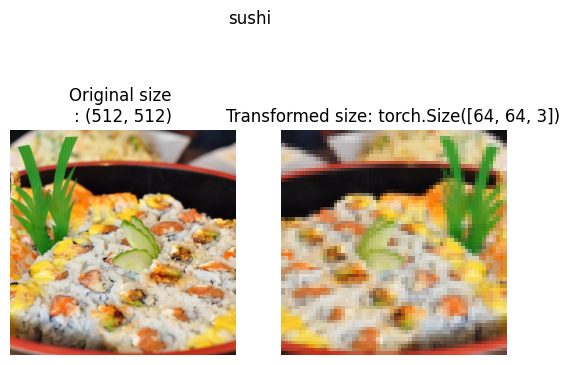

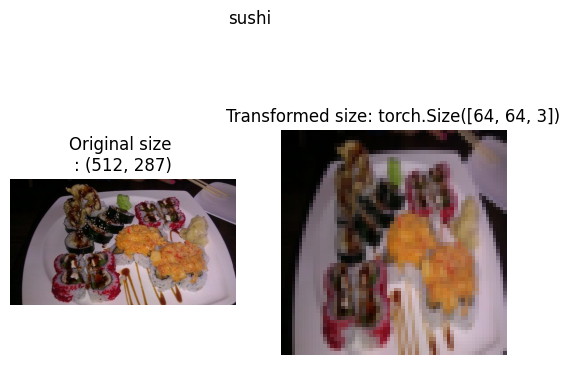

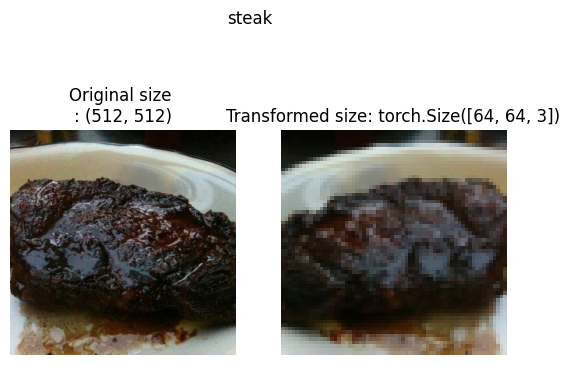

In [14]:
import random
import matplotlib.pyplot as plt

def plot_transformed_images(image_paths, transform, n=3, seed=42):
  """Plots a series of random images from image_paths.

Will open n image paths from image_paths, transform them
with transform and plot them side by side.

Args:
    image_paths (list): List of target image paths.
    transform (PyTorch Transforms): Transforms to apply to images.
    n (int, optional): Number of images to plot. Defaults to 3.
    seed (int, optional): Random seed for the random generator. Defaults to 42.
"""
  random.seed(seed)

  random_image_paths = random.sample(population=image_paths, k=n)

  for img_path in random_image_paths:
    with Image.open(img_path) as f:
      fig, ax = plt.subplots(1, 2)

      ax[0].imshow(f)
      ax[0].set_title(f"Original size \n: {f.size}")
      ax[0].axis("off")

      transformed_img = transform(f).permute(1, 2, 0)
      ax[1].imshow(transformed_img)
      ax[1].set_title(f"Transformed size: {transformed_img.shape}")
      ax[1].axis("off")

      fig.suptitle(img_path.parent.stem)

plot_transformed_images(img_path_list, transform_data)

## 4. Turning Image data into dataset

We'll turn our image data into a Dataset capable of being used with PyTorch.

### 4.1 Option 1: Loading Image Data Using `ImageFolder`

In [15]:
from torchvision import datasets

In [16]:
train_dataset = datasets.ImageFolder(root=train_dir,
                                     transform=transform_data,
                                     target_transform=None) # Do u want to transform labels?

test_dataset = datasets.ImageFolder(root=test_dir,
                                    transform=transform_data,
                                    target_transform=None)

In [17]:
train_dataset.classes, train_dataset.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [18]:
train_dataset[0][0].shape

torch.Size([3, 64, 64])

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

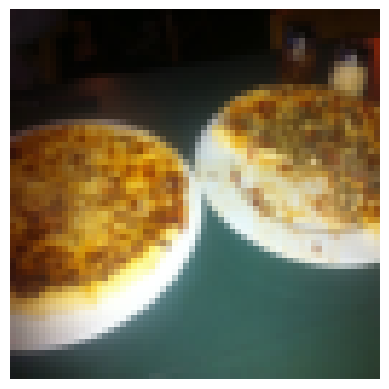

In [19]:
# plotting a single image
import matplotlib.pyplot as plt

plt.imshow(train_dataset[0][0].permute(1, 2, 0))
plt.axis("off")

#### 4.1.1 Turn loaded images into dataloader

In [20]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=1,
                              shuffle=True,
                              num_workers=1)

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=1,
                             shuffle=True,
                             num_workers=1)

What's `num_workers`?

It defines how many subprocesses will be created to load your data.

Think of it like this, the higher value num_workers is set to, the more compute power PyTorch will use to load your data.

E.g set it to the total number of CPUs on my machine via Python's `os.cpu_count()`

In [21]:
img, label = next(iter(train_dataloader))

img.shape, label.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1]))

### 4.2  Option 2: Loading Image Data with a Custom Dataset

What if a pre-built Dataset creator like torchvision.datasets.ImageFolder() didn't exist?

Or one for your specific problem didn't exist?

Well, you could build your own.

We'll replicate `torchvision.datasets.ImageFolder`

We'll need:

- Python's `os` for dealing with directories (our data is stored in directories).
- Python's `pathlib` for dealing with filepaths (each of our images has a unique filepath).
- `torch` for all things PyTorch.
- `PIL's` Image class for loading images.
- `torch.utils.data.Dataset` to subclass and create our own custom Dataset.
- `torchvision.transforms` to turn our images into tensors.
- Various types from Python's typing module to add type hints to our code.

In [22]:
import os
import pathlib
import torch

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from typing import Tuple, Dict, List

#### 4.2.1 Creating a helper function to get class names

We'll:

1. Get the class names using os.scandir() to traverse a target directory (ideally the directory is in standard image classification format).
2. Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure).
3. Turn the class names into a dictionary of numerical labels, one for each class.

In [23]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
  """Finds the class folder names in a target directory.

  Assumes target directory is in standard image classification format.

  Args:
      directory (str): target directory to load classnames from.

  Returns:
      Tuple[List[str], Dict[str, int]]: (list_of_class_names, dict(class_name: idx...))

  Example:
      find_classes("food_images/train")
      >>> (["class_1", "class_2"], {"class_1": 0, ...})
  """

  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

  class_to_idx = {class_name: index for index, class_name in enumerate(classes)}

  return classes, class_to_idx

In [24]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

#### 4.2.2 Create a custom Dataset to replicate ImageFolder

In [25]:
train_dataset = datasets.ImageFolder(root=train_dir,
                                     transform=transform_data,
                                     target_transform=None) # Do u want to transform labels?

In [26]:

class ImageFolderCustom(Dataset):
  def __init__(self, target_dir:str, transform=None):
    # Get all image paths
    self.paths = list(pathlib.Path(target_dir).glob("*/*.jpg")) # to be changed if image is other type e.g png
    # set up transforms
    self.transform = transform
    # create class and class_to_idx attributes
    self.classes, self.class_to_idx = find_classes(directory=target_dir)

  # Make function to load images
  def load_image(self, index) -> Image.Image:
    "Opens image via path and returns it"
    return Image.open(self.paths[index])

  # Override the __len__() method. Optional but recommended for subclasses of torch.utils.data.dataloader
  def __len__(self) -> int:
    "Returns total number of samples"
    return len(self.paths)

  # Overrrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
  def __getitem__(self, index: int):
    img = self.load_image(index)
    class_name = self.paths[index].parent.name
    class_idx = self.class_to_idx[class_name]

    if self.transform:
      return self.transform(img), class_idx
    else:
      return img, class_idx

In [27]:
# transforms
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [28]:
train_dataset_custom = ImageFolderCustom(target_dir=train_dir,
                                  transform=train_transform)

test_dataset_custom = ImageFolderCustom(target_dir=test_dir,
                                   transform=test_transform)

train_dataset_custom, test_dataset_custom

(<__main__.ImageFolderCustom at 0x7c452651af90>,
 <__main__.ImageFolderCustom at 0x7c452651a7e0>)

In [29]:
len(train_dataset_custom), len(test_dataset_custom)

(225, 75)

In [30]:
train_dataset_custom.classes, train_dataset_custom.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [31]:
print(len(train_dataset_custom) == len(train_dataset))
print(train_dataset_custom.classes == train_dataset.classes)
print(train_dataset_custom.class_to_idx == train_dataset.class_to_idx)

True
True
True


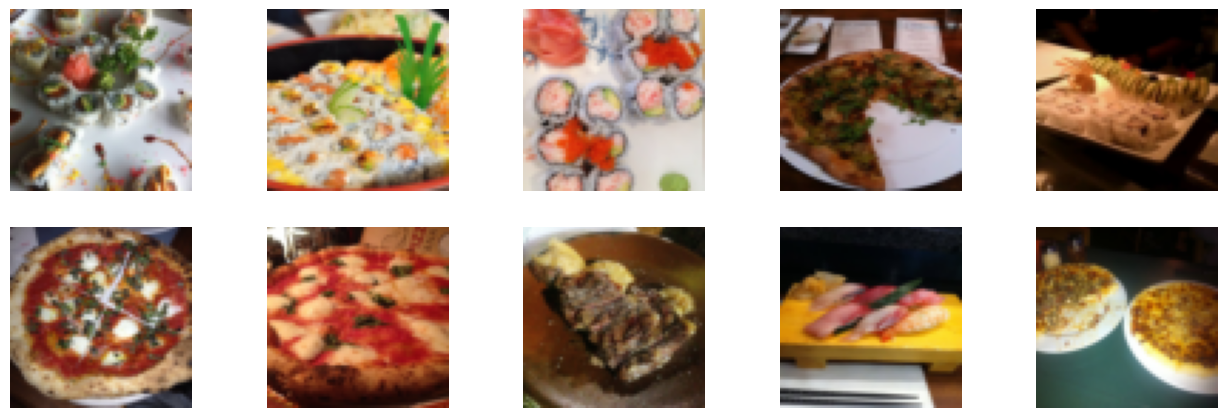

In [32]:
import random

def display_random_images(dataset:torch.utils.data.dataset.Dataset,
                          n: int = 10,
                          classes: List[str] = None,
                          display_shape: bool = True,
                          seed: int = None):
  if n > 10:
    print(f"For display purpose, n must not be more than 10. Setting n to 10 and remving shape display.")
    n = 10
    display_shape = False

  if seed:
    random.seed(seed)

  random_idxs = random.sample(population=range(len(dataset)), k=n)

  plt.figure(figsize=(16, 8))
  for i, sample in enumerate(random_idxs):
    img, label = dataset[sample][0], dataset[sample][1]
    plt.subplot(round(n / 5) + 1, 5, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")

    if classes:
      title = f"class : {classes[label]}"
      if display_shape:
        title += f"\nshape : {img.shape}"

display_random_images(train_dataset_custom, 10, ["pizza", "steak", "sushi"], 42)

For display purpose, n must not be more than 10. Setting n to 10 and remving shape display.


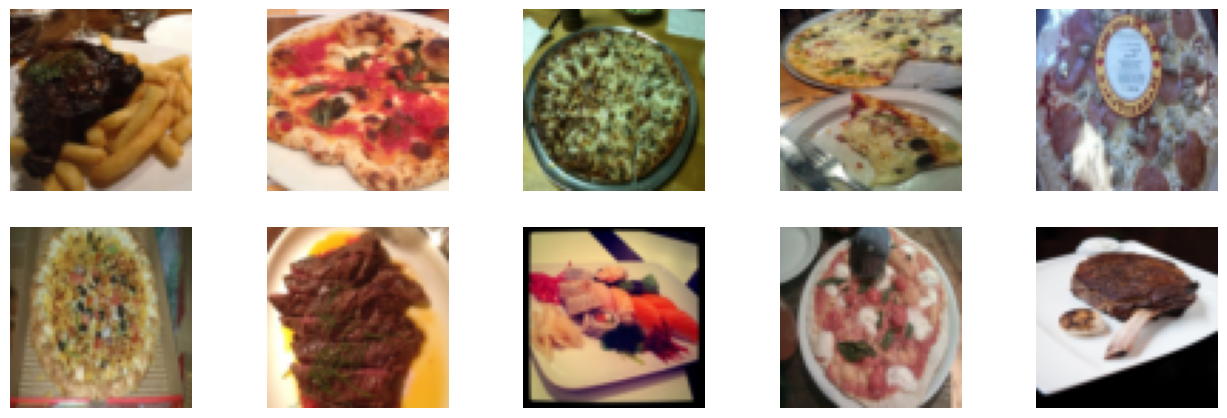

In [33]:
# for original dataset

display_random_images(train_dataset, 12, ["pizza", "steak", "sushi"], 42)

#### 4.2.3 Turn custom loaded images into DataLoader's

In [34]:
from torch.utils.data import DataLoader

train_dataloader_custom = DataLoader(dataset=train_dataset_custom,
                                     batch_size=1,
                                     num_workers=0,
                                     shuffle=True)
test_dataloader_custom = DataLoader(dataset=test_dataset_custom,
                                    batch_size=1,
                                    num_workers=0,
                                    shuffle=False)

In [35]:
next(iter(train_dataloader_custom))[0].shape

torch.Size([1, 3, 64, 64])

## 5. Other forms of transforms (data augmentation)

**Data augmentation** is the process of altering your data in such a way that you artificially increase the diversity of your training set.

Training a model on this artificially altered dataset hopefully results in a model that is capable of better generalization (the patterns it learns are more robust to future unseen examples).

You can see many different examples of data augmentation performed on images using `torchvision.transforms`.

The main parameter to pay attention to in `transforms.TrivialAugmentWide()` is `num_magnitude_bins=31`.

It defines how much of a range an intensity value will be picked to apply a certain transform, 0 being no range and 31 being maximum range (highest chance for highest intensity).

In [36]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

***Note :** You usually don't perform data augmentation on the test set. The idea of data augmentation is to to artificially increase the diversity of the training set to better predict on the testing set.*

*However, you do need to make sure your test set images are transformed to tensors. We size the test images to the same size as our training images too, however, inference can be done on different size images if necessary (though this may alter performance)*

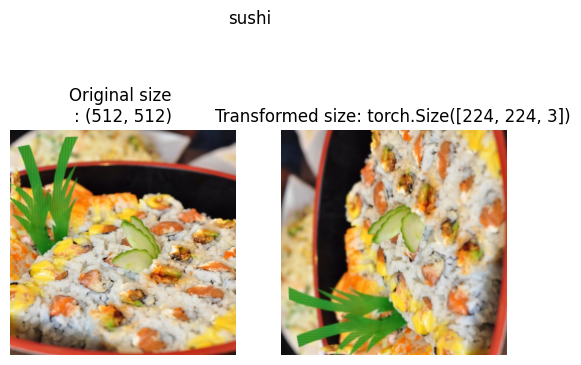

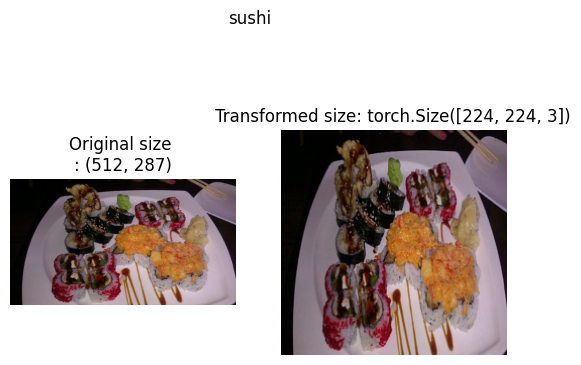

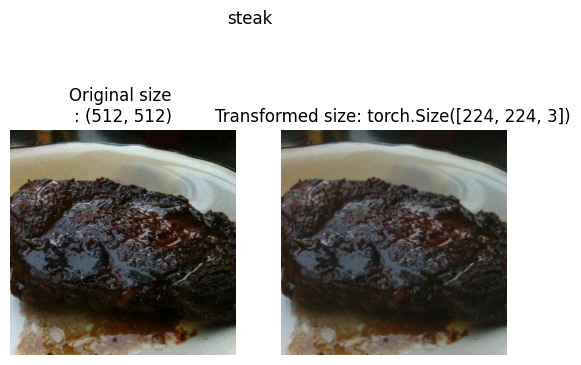

In [37]:
img_path_list = list(pathlib.Path(image_path).glob("*/*/*.jpg"))

plot_transformed_images(image_paths=img_path_list,
                        transform=train_transform)

## 6. Model 0: TinyVGG without data augmentation

In [38]:
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

### 6.1 Creating transforms and loading data for Model 0

In [39]:
from torchvision import datasets
from torch.utils.data import DataLoader
import os

# Load and transform data
simple_train_dataset = datasets.ImageFolder(root=train_dir,
                                           transform=simple_transform)

simple_test_dataset = datasets.ImageFolder(root=test_dir,
                                           transform=simple_transform)

# turn datasets into dataloaders
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

simple_train_dataloader = DataLoader(dataset=simple_train_dataset,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS)

simple_test_dataloader = DataLoader(dataset=simple_test_dataset,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

simple_train_dataloader, simple_test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c45262d3fe0>,
 <torch.utils.data.dataloader.DataLoader at 0x7c45262ae4b0>)

### 6.2 Create TinyVGG model class

In [40]:
import torch.nn as nn

class TinyVGG(nn.Module):
  def __init__(self, input_shape: int,
               hidden_units: int = 10,
               output_shape: int = 3):

    super().__init__()

    self.block1 = nn.Sequential(
        nn.Conv2d(input_shape, hidden_units, 3, 1, 1),
        nn.ReLU(),

        nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),
        nn.ReLU(),
        nn.MaxPool2d(3, 2)
    )

    self.block2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 3, 1),
        nn.ReLU(),

        nn.Conv2d(hidden_units, hidden_units, 3, 1),
        nn.MaxPool2d(2, 2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(1690, output_shape)
    )

  def forward(self, x):
    # # print(x.shape)
    # x = self.block1(x)
    # # print(x.shape)
    # x = self.block2(x)
    # # print(x.shape)
    # x = self.classifier(x)
    # # print(x.shape)
    # return x

    return self.classifier(self.block2(self.block1(x)))

torch.manual_seed(42)
model_0 = TinyVGG(3, 10, 3).to(device)

### 6.3 Testing forward pass on single image

In [41]:
img_batch, label_batch = next(iter(simple_train_dataloader))

img_single, label_single = img_batch[0], label_batch[0]

model_0.eval()
with torch.inference_mode():
  pred = model_0(img_single.unsqueeze(dim=0))

print(f"Output logits : {pred}")
print(f"prediction probabilities : {torch.softmax(input=pred, dim=1)}")
print(f"prediction labels : {torch.argmax(input=pred, dim=1)}")
print(f"actual labels : {label_single}")


Output logits : tensor([[ 0.0264, -0.0176,  0.0274]])
prediction probabilities : tensor([[0.3381, 0.3235, 0.3384]])
prediction labels : tensor([2])
actual labels : 0


### 6.4 Use `torchinfo` to get an idea of the shapes going through our model

Printing out our model with print(model) gives us an idea of what's going on with our model.
And we can print out the shapes of our data throughout the `forward()` method.

However, a helpful way to get information from our model is to use torchinfo.

`torchinfo` comes with a `summary()` method that takes a PyTorch model as well as an input_shape and returns what happens as a tensor moves through your model.

Note: If you're using Google Colab, you'll need to install torchinfo.

In [42]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

from torchinfo import summary

summary(model=model_0, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 31, 31]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 31, 31]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 29, 29]           910
│    └─ReLU: 2-7                         [1, 10, 29, 29]           --
│    └─Conv2d: 2-8                       [1, 10, 27, 27]           910
│    └─MaxPool2d: 2-9                    [1, 10, 13, 13]           --
├─Sequential: 1-3                        [1, 3]                    --
│    └─Flat

### 6.5 Create train & test loop functions

*repeated again in this notebook for pratice.*

In [43]:
from typing import Callable

def train_step(model: nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device=device):
  model.train()

  train_loss, acc = 0, 0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    # Forward pass
    pred = model(X)

    # Calculate loss
    loss = loss_fn(pred, y)
    train_loss += loss.item()
    acc += (torch.softmax(pred, dim=1).argmax(dim=1) == y).sum().item() / len(pred)

    # zero gradient
    optimizer.zero_grad()

    # back propogation
    loss.backward()

    # optimizer step
    optimizer.step()

  train_loss /= len(dataloader)
  acc /= len(dataloader)

  print(f"train loss : {train_loss}")
  print(f"train accuracy : {acc}")

  return train_loss, acc

In [44]:
def test_step(model: nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: nn.Module,
              device: torch.device=device):
  model.eval()
  test_loss, acc = 0, 0
  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      acc += (torch.softmax(pred, dim=1).argmax(dim=1) == y).sum().item() / len(pred)

    test_loss /= len(dataloader)
    acc /= len(dataloader)

    print(f"test loss : {test_loss}")
    print(f"test accuracy : {acc}")

  return test_loss, acc

Creating a `train()` function to combine `train_step()` and `test_step()`.

In [45]:
from tqdm.auto import tqdm

def train(model: nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: nn.Module=nn.CrossEntropyLoss(),
          epochs: int=5,
          device: torch.device=device):

  results = {
      "train_loss": [],
      "test_loss": [],
      "train_acc": [],
      "test_acc": []
  }

  for epoch in tqdm(range(epochs)):
    print(f"epoch : {epoch}\n----------")

    # do training - call train step
    train_loss, train_acc = train_step(model=model,
               dataloader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               device=device)

    # do testing - call test step
    test_loss, test_acc = test_step(model=model,
              dataloader=test_dataloader,
              loss_fn=loss_fn,
              device=device)

    # store values in results
    results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
    results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
    results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
    results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

  # return results
  return results

In [46]:
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

In [47]:
torch.manual_seed(42)

model_0_results = train(model=model_0,
      train_dataloader=simple_train_dataloader,
      test_dataloader=simple_test_dataloader,
      optimizer=optimizer,
      loss_fn=loss_fn)

  0%|          | 0/5 [00:00<?, ?it/s]

epoch : 0
----------
train loss : 1.1007521450519562
train accuracy : 0.4296875
test loss : 1.3831908106803894
test accuracy : 0.2604166666666667
epoch : 1
----------
train loss : 1.1080441176891327
train accuracy : 0.42578125
test loss : 1.1517589688301086
test accuracy : 0.2604166666666667
epoch : 2
----------
train loss : 1.0933574438095093
train accuracy : 0.42578125
test loss : 1.1487444043159485
test accuracy : 0.2604166666666667
epoch : 3
----------
train loss : 1.1098982393741608
train accuracy : 0.3046875
test loss : 1.1444682280222576
test accuracy : 0.19791666666666666
epoch : 4
----------
train loss : 1.0962668657302856
train accuracy : 0.3046875
test loss : 1.1442583799362183
test accuracy : 0.2604166666666667


It looks like our model performed pretty poorly.

But that's okay for now, we'll keep persevering.

### 6.6 Plotting the loss curves

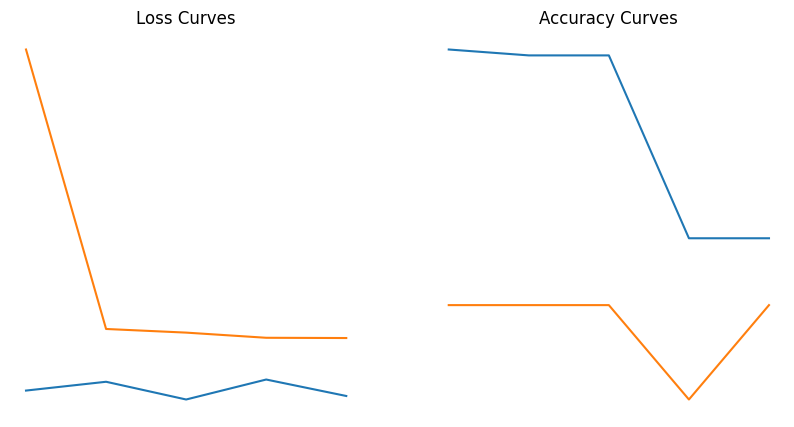

In [51]:
import matplotlib.pyplot as plt

def plot_loss_curves(results: Dict[str, List[float]]):
  """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
  """

  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.plot(results["train_loss"], label="train loss")
  plt.plot(results["test_loss"], label="test loss")
  plt.axis("off")
  plt.title("Loss Curves")

  plt.subplot(1, 2, 2)
  plt.plot(results["train_acc"], label="train accuracy")
  plt.plot(results['test_acc'], label="test accuracy")
  plt.axis("off")
  plt.title("Accuracy Curves")

plot_loss_curves(results=model_0_results)


## 7. What an ideal loss curve be like?

Looking at training and test loss curves is a great way to see if your model is overfitting.

An overfitting model is one that performs better (often by a considerable margin) on the training set than the validation/test set.

If your training loss is far lower than your test loss, your model is overfitting.

As in, it's learning the patterns in the training too well and those patterns aren't generalizing to the test data.

The other side is when your training and test loss are not as low as you'd like, this is considered underfitting.

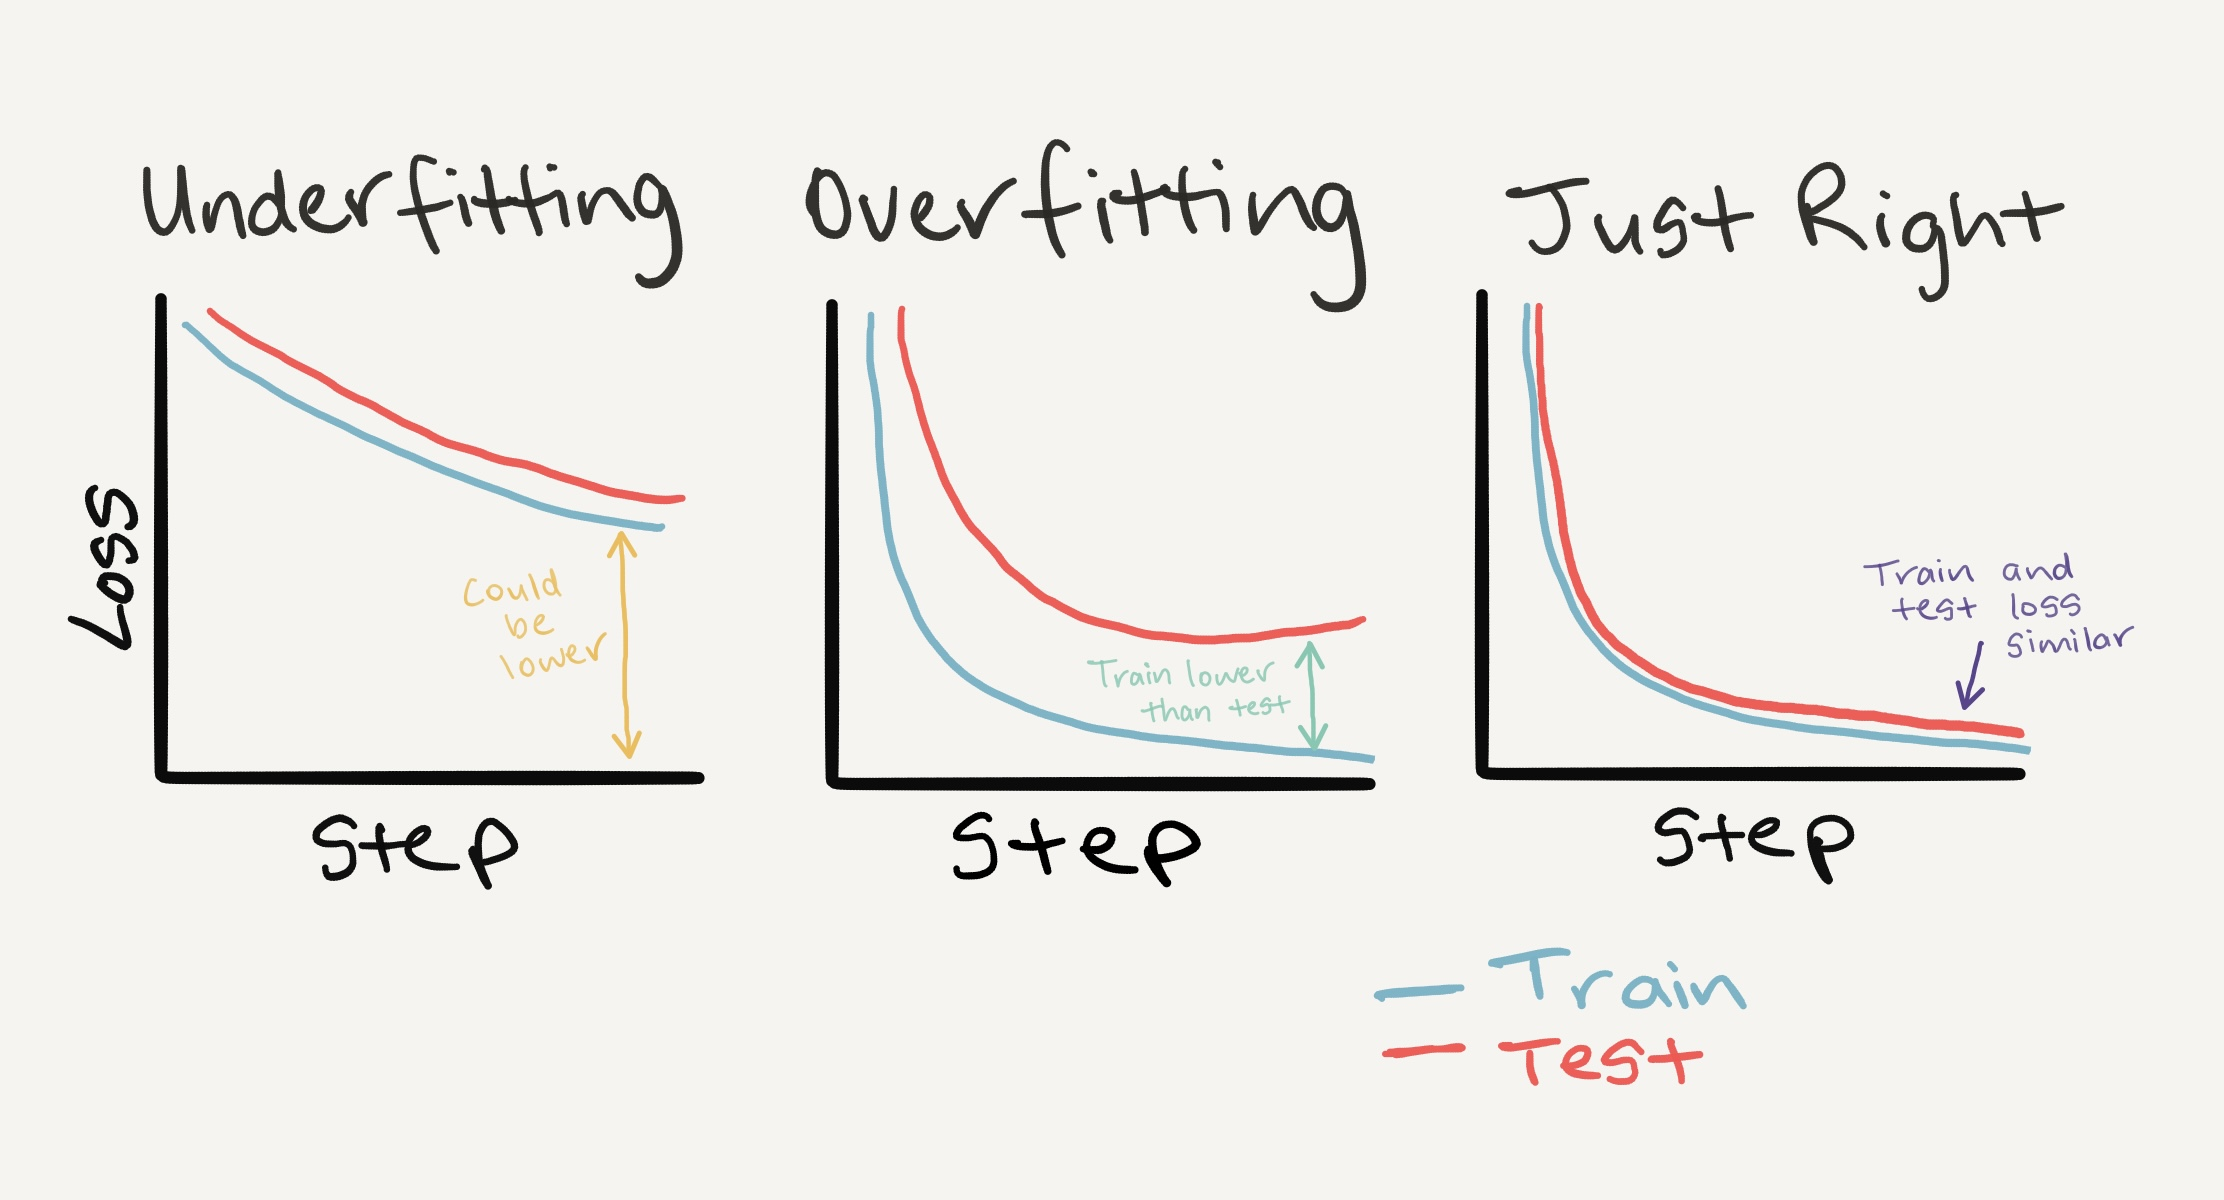

### 7.1  How to deal with overfitting

A common technique of preventing overfitting is known as `regularization`.

I like to think of this as "making our models more regular", as in, capable of fitting more kinds of data.

see more techniques:
https://www.ibm.com/think/topics/overfitting

| **Method to Prevent Overfitting** | **What is it?**                                                                                                                                                                                                                                   |
| --------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Get more data**                 | Having more data gives the model more opportunities to learn patterns that may generalize better to new examples.                                                                                                                                 |
| **Simplify your model**           | If the model is overfitting, it may be too complex. You can simplify it by reducing the number of layers or hidden units.                                                                                                                         |
| **Use data augmentation**         | Data augmentation artificially adds variety to the training data by modifying existing examples. This makes it harder for the model to simply memorize the training data and can improve generalization.                                          |
| **Use transfer learning**         | Transfer learning uses patterns (pretrained weights) learned by another model as a starting point for your own task. For example, you could use a computer vision model pretrained on a large image dataset and adapt it to classify food images. |
| **Use dropout layers**            | Dropout randomly removes connections/activations during training, which helps prevent the model from relying too heavily on specific neurons and can reduce overfitting.                                                                          |
| **Use learning rate decay**       | Gradually decrease the learning rate as training progresses. As the model gets closer to convergence, smaller weight updates can help it settle on better values.                                                                                 |
| **Use early stopping**            | Stop training before the model begins to overfit. For example, if validation loss stops improving for several epochs, you can stop training and keep the model weights from the epoch with the best validation performance.                       |


### 7.2 How to deal with underfitting
hen a model is underfitting it is considered to have poor predictive power on the training and test sets.

In essence, an underfitting model will fail to reduce the loss values to a desired level.

Right now, looking at our current loss curves, I'd considered our TinyVGG model, model_0, to be underfitting the data.

See more at:

https://www.ibm.com/think/topics/underfitting#1759735863

| **Method to Prevent Underfitting**      | **What is it?**                                                                                                                                                                                             |
| --------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Add more layers/units to your model** | If your model is underfitting, it may not have enough capacity to learn the required patterns and representations in the data. You can increase its predictive power by adding more hidden layers or units. |
| **Tweak the learning rate**             | The learning rate may be too high, causing the model to make weight updates that are too large. Lowering the learning rate may allow the model to learn more effectively.                                   |
| **Use transfer learning**               | Transfer learning uses patterns learned by a previously trained model and adapts them to your own problem. It can help prevent both overfitting and underfitting.                                           |
| **Train for longer**                    | Sometimes a model simply needs more training time to learn useful representations. Increasing the number of epochs may improve performance.                                                                 |
| **Use less regularization**             | Too much regularization can prevent the model from learning the training data effectively. Reducing regularization can allow the model to fit the data better.                                              |


### 8.3 The balance between overfitting and underfitting

one of the methods discussed above are silver bullets, meaning, they don't always work.

And preventing overfitting and underfitting is possibly the most active area of machine learning research.

Since everyone wants their models to fit better (less underfitting) but not so good they don't generalize well and perform in the real world (less overfitting).

There's a fine line between overfitting and underfitting.

Because too much of each can cause the other.

Transfer learning is perhaps one of the most powerful techniques when it comes to dealing with both overfitting and underfitting on your own problems.

Rather than handcraft different overfitting and underfitting techniques, transfer learning enables you to take an already working model in a similar problem space to yours (say one from `paperswithcode.com/sota` or `Hugging Face models`) and apply it to your own dataset.

## 8. Model 1: TinyVGG with Data Augmentation

let' see if augumentation improves results. We'll try `transforms.TrivialAugmentWide()` in training part

### 8.1 Make transforms

In [52]:
trivial_augument_train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

### 8.2 make datasets and data loaders for train and test split

In [53]:
from torchvision import datasets
from torch.utils.data import DataLoader
import os

train_dataset_aug = datasets.ImageFolder(root=train_dir,
                                         transform=trivial_augument_train_transform)

test_dataset = datasets.ImageFolder(root=test_dir,
                                    transform=test_transform)

In [54]:
torch.manual_seed(42)

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_aug = DataLoader(dataset=train_dataset_aug,
                                  batch_size=BATCH_SIZE,
                                  num_workers=NUM_WORKERS,
                                  shuffle=True)

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS,
                             shuffle=False)

### 8.3 Construct and train model 1

In [55]:
torch.manual_seed(42)

model_1 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=3).to(device)

model_1

TinyVGG(
  (block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [56]:
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [57]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_1_results = train(model=model_1,
      train_dataloader=train_dataloader_aug,
      test_dataloader=test_dataloader,
      loss_fn=nn.CrossEntropyLoss(),
      optimizer=optimizer,
      epochs=5)

  0%|          | 0/5 [00:00<?, ?it/s]

epoch : 0
----------
train loss : 1.10176782310009
train accuracy : 0.39453125
test loss : 1.3484755754470825
test accuracy : 0.2604166666666667
epoch : 1
----------
train loss : 1.1070241332054138
train accuracy : 0.42578125
test loss : 1.156858007113139
test accuracy : 0.2604166666666667
epoch : 2
----------
train loss : 1.0943228006362915
train accuracy : 0.42578125
test loss : 1.1519024570782979
test accuracy : 0.2604166666666667
epoch : 3
----------
train loss : 1.1099966317415237
train accuracy : 0.3046875
test loss : 1.14283021291097
test accuracy : 0.19791666666666666
epoch : 4
----------
train loss : 1.0976213067770004
train accuracy : 0.29296875
test loss : 1.1430569489796956
test accuracy : 0.2604166666666667


same results

### 8.4 Plot the loss curves of Model 1

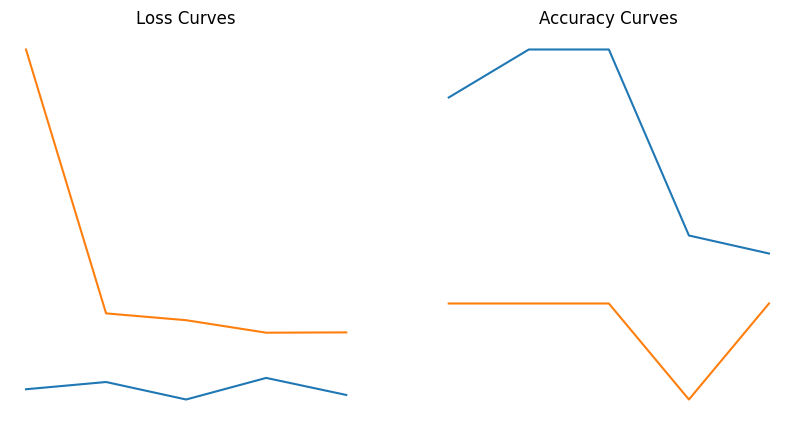

In [58]:
plot_loss_curves(model_1_results)

## 9. Compare model results

both have about same results

In [59]:
import pandas as pd

model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)

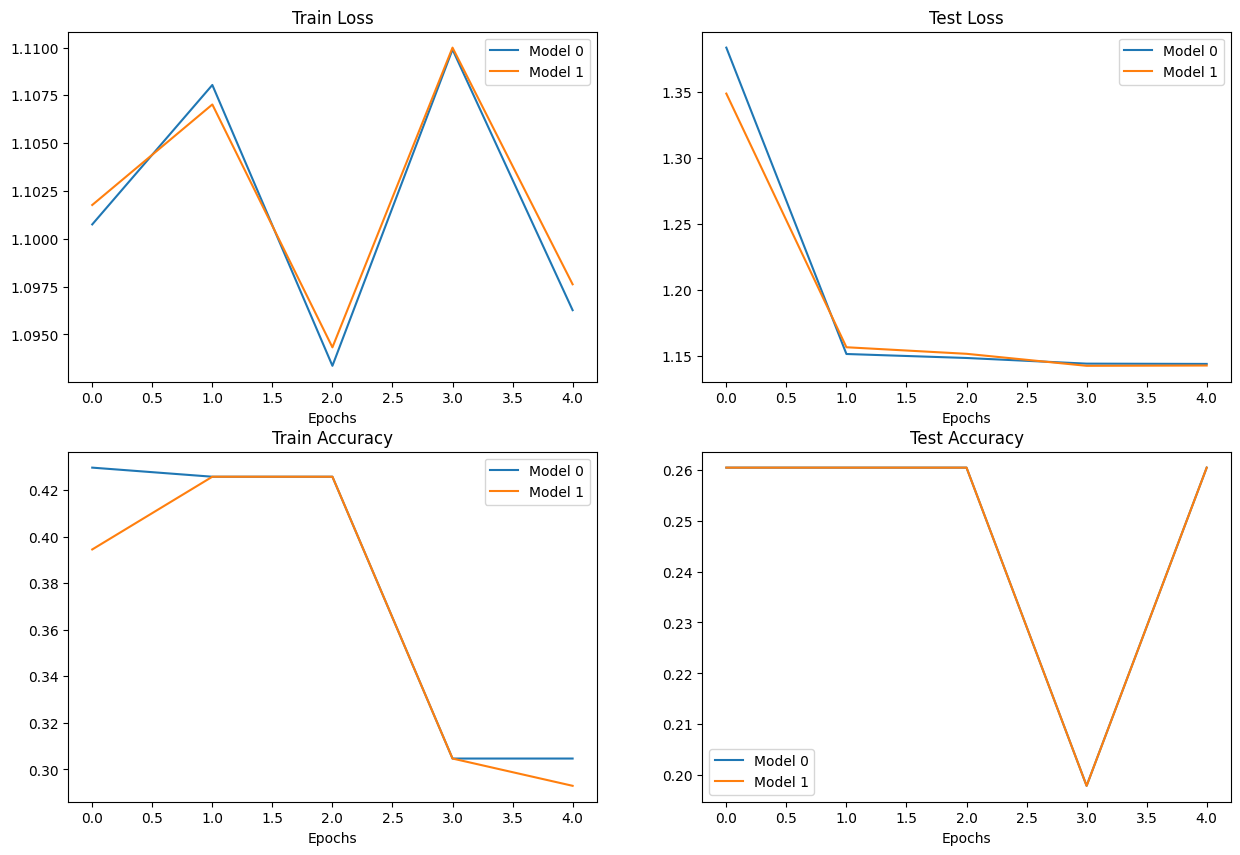

In [60]:
# Setup a plot
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend();

## 11. Making prediction on a custom image

In [78]:
import requests

custom_img_path = data_path / "random_pizza_image.jpg"

if not custom_img_path.is_file():
  with open(custom_img_path, "wb") as f:
    print("dpwnloading the image...")
    req = requests.get("https://raw.githubusercontent.com/Faizan-Rashid/deep-learning-pytorch/refs/heads/main/images/random_pizza_image.jpg")
    f.write(req.content)

In [82]:
import torchvision
img = torchvision.io.read_image(custom_img_path)

print(f"Custom image shape: {img.shape}")
print(f"Custom image dtype: {img.dtype}")
print(f"Custom image tensor", img)